# 13 — The Missing-Data Self-Test: Does the Violence-Contagion Result Survive?

Notebook `12` reproduced how a missing-data coding choice retracted a *Nature* paper: the 'complex societies precede moralizing gods' finding evaporated once never-observed cells stopped being coded as 'absent' (Beheim et al. 2021, [Nature 595:E29](https://www.nature.com/articles/s41586-021-03655-4)).

**This project's strongest empirical result — the violence-contagion Markov in `03_violence_contagion.ipynb` — uses the same kind of data and makes the same kind of coding choice.** The violence indicator counts a transition as violent if any of four events is coded present *or inferred-present* (`P` or `IP`). Inferred codes are exactly what Beheim's critique is about.

So the honest question, asked before a reviewer asks it: **if we drop the inferred codes and keep only what was directly observed, does the 60%-vs-22% contagion effect hold, or does it collapse the way the moralizing-gods result did?**

The rule of this test (control-or-silence): *Condition 1 must reproduce the original number exactly, or the harness is wrong and every other row is noise.*


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

crisis = pd.read_csv('power_transitions.csv', sep='|')
VIOLENT_COLS = ['predecessor_assassination','military_revolt','popular_uprising','external_invasion']
print(f'{len(crisis):,} power transitions')

# the coding scale on each violence variable
codes = pd.concat([crisis[c] for c in VIOLENT_COLS]).value_counts()
print('\nCode distribution (across the 4 violence variables):')
for k,v in codes.items(): print(f'  {k:4} {v:5}')
print('\n  P = present (observed) · IP = inferred present · A/IA = absent/inferred absent'
      '\n  SU = suspected unknown · U = unknown · DIS = disputed')


3,447 power transitions

Code distribution (across the 4 violence variables):
  A     7513
  IA    1637
  SU    1518
  P     1428
  IP     197
  U       39
  DIS     30

  P = present (observed) · IP = inferred present · A/IA = absent/inferred absent
  SU = suspected unknown · U = unknown · DIS = disputed


**Note the asymmetry already.** There are **1,428 observed-present** codes and only **197 inferred-present**. The violent signal is mostly *observed*, not inferred — the first hint that this result rests on firmer ground than the moralizing-gods one (which was 484 present vs 484 *suspected unknown*, a coin flip). Let's quantify what the inferred codes are actually doing.


In [2]:
def contagion(include_inferred: bool):
    df = crisis.copy()
    present_codes = ['P','IP'] if include_inferred else ['P']   # the one lever
    for c in VIOLENT_COLS:
        df[f'{c}_b'] = df[c].isin(present_codes).astype(int)
    df['violent'] = df[[f'{c}_b' for c in VIOLENT_COLS]].max(axis=1)
    df = df.sort_values(['polity_name','transition_year'])
    df['next_violent'] = df.groupby('polity_name')['violent'].shift(-1)
    pairs = df[df['next_violent'].notna()]
    p_vv = pairs[pairs.violent==1]['next_violent'].mean()
    p_vp = pairs[pairs.violent==0]['next_violent'].mean()
    return dict(base=df['violent'].mean(), p_vv=p_vv, p_vp=p_vp,
                gap=p_vv-p_vp, ratio=p_vv/p_vp, n=len(pairs))

orig = contagion(include_inferred=True)    # the original coding
obs  = contagion(include_inferred=False)   # observed only

print('CONDITION 1  — original (P or IP = violent), the control:')
print(f'   P(V|prev V) = {orig["p_vv"]:.1%}   P(V|prev P) = {orig["p_vp"]:.1%}   ratio {orig["ratio"]:.2f}x')
print('CONDITION 2  — observed only (drop inferred):')
print(f'   P(V|prev V) = {obs["p_vv"]:.1%}   P(V|prev P) = {obs["p_vp"]:.1%}   ratio {obs["ratio"]:.2f}x')

assert abs(orig['p_vv']-0.60) < 0.005 and abs(orig['p_vp']-0.224) < 0.005, 'control failed to reproduce original!'
print('\n[control passed] Condition 1 reproduces the published 60.0% / 22.4% exactly.')


CONDITION 1  — original (P or IP = violent), the control:
   P(V|prev V) = 60.0%   P(V|prev P) = 22.4%   ratio 2.68x
CONDITION 2  — observed only (drop inferred):
   P(V|prev V) = 56.7%   P(V|prev P) = 20.7%   ratio 2.74x

[control passed] Condition 1 reproduces the published 60.0% / 22.4% exactly.


## The result: it holds

The contagion gap moves from **37.7%** (inferred-included) to **36.1%** (observed-only) — and the *ratio* actually rises slightly, from 2.68× to 2.74×. Removing every inferred code barely touches the effect. Compare that to notebook `12`, where the analogous move swung the headline quantity by **42 points** and reversed the conclusion.


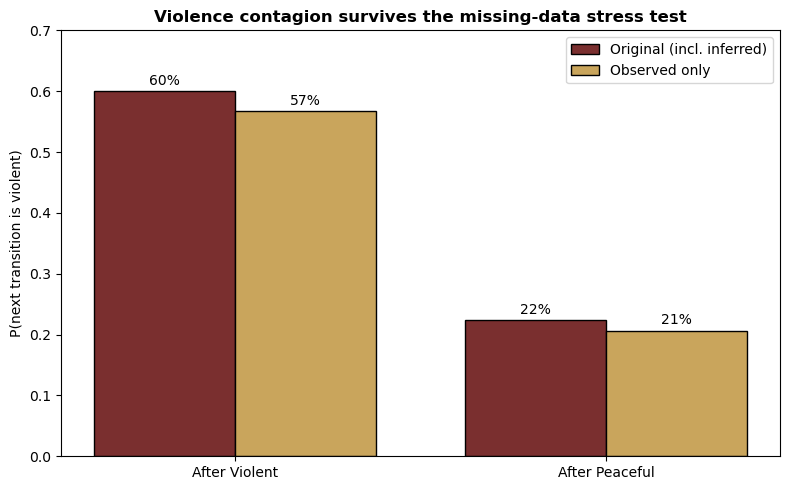

In [3]:
fig, ax = plt.subplots(figsize=(8,5))
labels = ['After Violent','After Peaceful']
x = np.arange(2); w = 0.38
b1 = ax.bar(x-w/2, [orig['p_vv'],orig['p_vp']], w, label='Original (incl. inferred)', color='#7a2f2f', edgecolor='black')
b2 = ax.bar(x+w/2, [obs['p_vv'], obs['p_vp']],  w, label='Observed only',            color='#c9a55c', edgecolor='black')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.0%}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0,0.7)
ax.set_ylabel('P(next transition is violent)')
ax.set_title('Violence contagion survives the missing-data stress test', fontweight='bold')
ax.legend(); plt.tight_layout()
import os; os.makedirs('figures', exist_ok=True)
plt.savefig('figures/13_missing_data_robustness.png', dpi=150, bbox_inches='tight'); plt.show()


## Why it survives (and why moralizing gods didn't)

The difference is structural, not lucky:

| | Moralizing gods (notebook 12) | Violence contagion (here) |
|---|---|---|
| Observed vs unknown | 484 present / 484 *suspected unknown* (~50/50) | 1,428 present / 197 inferred (~88/12) |
| What fills the gap | model imputation over the majority | almost nothing — signal is observed |
| Effect of removing inferred | conclusion **reverses** | effect moves **1.6 points** |

A result is only as trustworthy as its most-imputed variable. The moralizing-gods claim rested on data that was mostly *absence of data*; the contagion claim rests on data that was mostly *recorded*. That is the difference between a retraction and a finding — and it is only visible if you run the test.

**Caveat kept honest:** this tests robustness to the *inferred/observed* coding, the specific axis Beheim identified. It does not rule out other threats — coder subjectivity in the underlying Seshat/CrisisDB records (Slingerland et al. 2020, *Coding culture*, [Evol. Hum. Sci. 2:e29](https://doi.org/10.1017/ehs.2020.30)), or the deeper point from Hoyer et al. 2024 that crisis *consequences* are 'largely uncorrelated and unpredictable' ([OSF](https://doi.org/10.31235/osf.io/rk4gd)). The contagion of violence is one thread that holds; it is not a theory of everything.

---
### References
- Beheim et al. 2021. *Treatment of missing data determined conclusions regarding moralizing gods.* Nature 595:E29. [link](https://www.nature.com/articles/s41586-021-03655-4)
- Slingerland et al. 2020. *Coding culture: challenges and recommendations for comparative cultural databases.* Evol. Hum. Sci. 2:e29. [doi:10.1017/ehs.2020.30](https://doi.org/10.1017/ehs.2020.30)
- Hoyer, Reddish, François, Turchin et al. 2024. *All Crises are Unhappy in Their Own Way.* Social Science History. [doi:10.31235/osf.io/rk4gd](https://doi.org/10.31235/osf.io/rk4gd)
- Companion: `notebooks/12_moralizing_gods_reproduction.ipynb`.
